# 14 — End-to-end demonstration: sky-frame grating angle with sigma_WCS

Full pipeline on both project test images: star detection -> plate solve
-> spatially-stratified WCS-orientation bootstrap (`sigma_WCS`) -> trace
detection/fit/combine (`extractor.measure_grating_angle`) -> final
sky-frame angle `theta_sky_deg +/- theta_sky_uncertainty_deg`, where the
uncertainty is `theta_pix_uncertainty_deg` (trace-ensemble bootstrap) and
`sigma_wcs_deg` (WCS-orientation bootstrap) combined in quadrature.

**This notebook also demonstrates a real bug found and fixed this
session** in `extractor/wcs_uncertainty.py`: on the sim image, the
full-source-list "fiducial" plate solve locked onto a confidently-wrong
answer 6 deg away from the correct orientation (confirmed against the
sim's own ground truth, `ROTDEG=0.0`). `bootstrap_wcs_orientation` now
cross-checks the fiducial against its own bootstrap population and falls
back to the (now also outlier-clipped) bootstrap median when they
disagree -- see `WcsBootstrapResult.fiducial_is_outlier` in the sim
section below, where it fires for real.

**Kernel:** `Python (spectrangle WSL)`


---
## Setup

In [1]:
import sys, warnings, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning

_pkg = str(Path('..').resolve())
if _pkg not in sys.path:
    sys.path.insert(0, _pkg)

from extractor import extract_stars, measure_grating_angle
from extractor.platesolve import solve_plate
from extractor.wcsangle import center_wcs_angle_metrics, angle_diff_deg
from extractor.wcs_uncertainty import bootstrap_wcs_orientation, stratified_bootstrap_indices

warnings.filterwarnings('ignore', message=r".*all_world2pix.*", category=UserWarning, module=r'astropy\.wcs')

BACKEND_CFG = '/mnt/c/Users/bassd/.astrometry/backend.cfg'
OUT_DIR = Path('..') / 'out' / 'wcs_bootstrap_demo'
OUT_DIR.mkdir(parents=True, exist_ok=True)


def _make_wcs(header):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FITSFixedWarning)
        warnings.filterwarnings('ignore', message='.*datfix.*')
        return WCS(header)


print('Setup complete.')


Setup complete.


---
## Helper functions

Compass/legend drawing style follows the earlier proposal figure
(`notebooks/archive/19_proposal_figure_real.ipynb`), extended to also
overlay detected diffraction traces and the ensemble orientation line
(driven by the actual `measure_grating_angle` result, not a manually
set angle), plus bootstrap-distribution diagnostic plots.


In [2]:
def stretch(raw, lo_pct, hi_pct, gamma):
    lo = float(np.percentile(raw, lo_pct))
    hi = float(np.percentile(raw, hi_pct))
    d = np.clip((raw - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)
    return d ** gamma if gamma != 1.0 else d


def draw_compass(ax, metrics, x_px, y_px, L, color='#ffe066', fs=18):
    """N and E arrows from (x_px, y_px) with length L (pixels)."""
    pix = ax.get_transform('pixel')
    for ang, frac, lw, ms, lbl in [
        (metrics.north_angle_deg, 1.00, 2.8, 22, 'N'),
        (metrics.east_angle_deg, 0.65, 2.2, 16, 'E'),
    ]:
        th = np.radians(ang)
        dx, dy = L * frac * np.cos(th), L * frac * np.sin(th)
        ax.annotate('', xy=(x_px + dx, y_px + dy), xytext=(x_px, y_px),
                    xycoords=pix, textcoords=pix,
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw, mutation_scale=ms))
        ax.text(x_px + 1.28 * dx, y_px + 1.28 * dy, lbl, transform=pix, color=color,
                fontsize=fs, fontweight='bold', ha='center', va='center')


def draw_double_arrow(ax, x_px, y_px, L, pix_angle_deg, color, lw=2.5, mutation_scale=20):
    """Double-headed arrow of total length L centred on (x_px, y_px) -- for
    an axial (180-symmetric) direction like a grating/trace orientation."""
    pix = ax.get_transform('pixel')
    th = np.radians(pix_angle_deg)
    cx_th, cy_th = np.cos(th), np.sin(th)
    half = L / 2.0
    ax.plot([x_px - half * cx_th, x_px + half * cx_th],
            [y_px - half * cy_th, y_px + half * cy_th],
            color=color, linewidth=lw, transform=pix, solid_capstyle='butt', zorder=6)
    for sign in (+1, -1):
        tip = (x_px + sign * half * cx_th, y_px + sign * half * cy_th)
        tail = (x_px + sign * half * 0.60 * cx_th, y_px + sign * half * 0.60 * cy_th)
        ax.annotate('', xy=tip, xytext=tail, xycoords=pix, textcoords=pix,
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw, mutation_scale=mutation_scale),
                    zorder=7)


def draw_traces(ax, trace_measurements, color='#33ccff', lw=1.2, alpha=0.85, len_scale=1.0):
    """Short line segment per detected trace at its own centroid/angle/length."""
    pix = ax.get_transform('pixel')
    for m in trace_measurements:
        th = np.radians(m.theta_pix_deg)
        half = 0.5 * len_scale * m.length_px
        dx, dy = half * np.cos(th), half * np.sin(th)
        ax.plot([m.x_center - dx, m.x_center + dx], [m.y_center - dy, m.y_center + dy],
                color=color, linewidth=lw, alpha=alpha, transform=pix, zorder=5)


def get_matched_stars_for_display(xs, ys, image_shape, boot_result, scale_low, scale_high,
                                   tweak_order=5, agree_tol_deg=1.0, seed=777):
    """The bootstrap's own re-solves don't retain their correspondence
    tables (only the header). For the matched-star overlay we need a
    fresh solve WITH a corr_table -- but re-solving on the FULL source
    list is exactly the call that can hit the false-match failure found
    this session (see module docstring in wcs_uncertainty.py). So we
    solve on a fresh stratified subset instead (matches the population
    the bootstrap already validated as reliable) and cross-check its
    north_angle_deg against the already-trusted boot_result before using
    its matched stars for display."""
    rng = np.random.default_rng(seed)
    idx = stratified_bootstrap_indices(xs, ys, image_shape, n_grid=(3, 3), frac=0.95, rng=rng)
    r = solve_plate(
        xs=xs[idx], ys=ys[idx], image_width=image_shape[1], image_height=image_shape[0],
        backend='local', backend_config=BACKEND_CFG, scale_units='arcsecperpix',
        scale_low=scale_low, scale_high=scale_high, tweak_order=tweak_order, timeout=180, verbose=False,
    )
    m = center_wcs_angle_metrics(_make_wcs(r.header), image_shape, compute_east=True)
    offset = angle_diff_deg(m.north_angle_deg, boot_result.north_angle_deg)
    if abs(offset) > agree_tol_deg:
        print(f'  WARNING: display cross-check solve disagrees with trusted bootstrap result '
              f'by {offset:.3f} deg (> {agree_tol_deg} deg tolerance) -- matched-star overlay '
              f'may not reflect the trusted orientation.')
    else:
        print(f'  Display cross-check solve agrees with bootstrap result to {offset:.4f} deg. OK.')
    mx = r.matched_x if len(r.matched_x) else np.array([])
    my = r.matched_y if len(r.matched_y) else np.array([])
    return mx, my, offset


print('Helpers defined.')


Helpers defined.


In [3]:
def run_pipeline_for_image(label, image_path, source_cache, wcs_boot_cache,
                            scale_low, scale_high, tweak_order,
                            min_length_px, min_eccentricity,
                            n_boot_wcs=10, boot_frac=0.9, n_grid=(3, 3), seed=42):
    print(f'=== {label} ===')
    with fits.open(image_path) as h:
        image = h[0].data.astype(np.float64)
        orig_header = h[0].header.copy()
    ny, nx = image.shape
    print(f'Image: {image_path.name}  shape={ny}x{nx}')

    if source_cache.exists():
        with open(source_cache, 'rb') as f:
            xs, ys, fluxes = pickle.load(f)
        print(f'Sources: {len(xs)} (cached)')
    else:
        xs, ys, fluxes = extract_stars(image.astype(np.float32), max_sources=300, mask_spectra=True)
        source_cache.parent.mkdir(parents=True, exist_ok=True)
        with open(source_cache, 'wb') as f:
            pickle.dump((xs, ys, fluxes), f)
        print(f'Sources: {len(xs)} (fresh)')

    if wcs_boot_cache.exists():
        with open(wcs_boot_cache, 'rb') as f:
            boot = pickle.load(f)
        print(f'WCS bootstrap: cached (n_boot_ok={boot.n_boot_ok}/{boot.n_boot_requested})')
    else:
        boot = bootstrap_wcs_orientation(
            xs, ys, (ny, nx), original_header=orig_header,
            n_boot=n_boot_wcs, boot_frac=boot_frac, n_grid=n_grid,
            backend='local', backend_config=BACKEND_CFG,
            scale_units='arcsecperpix', scale_low=scale_low, scale_high=scale_high,
            tweak_order=tweak_order, timeout=180, seed=seed,
        )
        wcs_boot_cache.parent.mkdir(parents=True, exist_ok=True)
        with open(wcs_boot_cache, 'wb') as f:
            pickle.dump(boot, f)
        print(f'WCS bootstrap: fresh (n_boot_ok={boot.n_boot_ok}/{boot.n_boot_requested})')

    print(f'  north_angle_deg = {boot.north_angle_deg:.4f}  sigma = {boot.sigma_north_deg:.4f}  mad = {boot.mad_north_deg:.4f}')
    if boot.fiducial_is_outlier:
        print(f'  *** fiducial_is_outlier=True: raw fiducial solve ({boot.fiducial_north_deg:.4f} deg) '
              f'disagreed with the bootstrap population by {boot.fiducial_offset_deg:.4f} deg -- fell back '
              f'to the bootstrap median. See extractor/wcs_uncertainty.py module docstring. ***')
    if boot.n_boot_clipped:
        print(f'  note: {boot.n_boot_clipped} individual bootstrap draw(s) excluded from sigma/mad as outliers.')

    wcs = _make_wcs(boot.header)
    metrics = center_wcs_angle_metrics(wcs, (ny, nx), compute_east=True)

    mx, my, disp_offset = get_matched_stars_for_display(xs, ys, (ny, nx), boot, scale_low, scale_high, tweak_order)

    result = measure_grating_angle(
        image, wcs=wcs, sigma_wcs_deg=boot.sigma_north_deg,
        min_length_px=min_length_px, min_eccentricity=min_eccentricity,
    )
    print(f'  theta_pix = {result.theta_pix_deg:.4f} +/- {result.theta_pix_uncertainty_deg:.4f} deg '
          f'(n_traces {result.n_traces_used}/{result.n_traces_detected}, quality R={result.quality:.4f})')
    print(f'  theta_sky = {result.theta_sky_deg:.4f} +/- {result.theta_sky_uncertainty_deg:.4f} deg')

    return dict(label=label, image=image, orig_header=orig_header, xs=xs, ys=ys,
                boot=boot, wcs=wcs, metrics=metrics, mx=mx, my=my, result=result)


print('Pipeline runner defined.')


Pipeline runner defined.


---
## Sim image (`110lmm50mm.fits`, known truth `MASKANG=23.0 deg`)

In [4]:
SIM_TRUTH_DEG = 23.0  # MASKANG from the FITS header -- ground truth for theta_pix

sim = run_pipeline_for_image(
    'sim: 110lmm50mm.fits', Path('..') / 'data' / '110lmm50mm.fits',
    Path('..') / 'out' / 'local_bootstrap_15' / 'sources.pkl',
    Path('..') / 'out' / 'local_bootstrap_15' / 'wcs_bootstrap_result_fixed.pkl',
    scale_low=8.0, scale_high=12.0, tweak_order=5,
    min_length_px=80.0, min_eccentricity=0.85,
)


=== sim: 110lmm50mm.fits ===


Image: 110lmm50mm.fits  shape=2080x3096
Sources: 287 (cached)
WCS bootstrap: cached (n_boot_ok=10/10)
  north_angle_deg = 90.0025  sigma = 0.0033  mad = 0.0028
  *** fiducial_is_outlier=True: raw fiducial solve (96.1498 deg) disagreed with the bootstrap population by 6.1473 deg -- fell back to the bootstrap median. See extractor/wcs_uncertainty.py module docstring. ***
  note: 2 individual bootstrap draw(s) excluded from sigma/mad as outliers.


  Display cross-check solve agrees with bootstrap result to -0.0041 deg. OK.


  theta_pix = 23.0078 +/- 0.0677 deg (n_traces 25/25, quality R=0.9999)
  theta_sky = 66.9707 +/- 0.0678 deg


---
## Real image (`fuji6_asi178_100_15s.fit`, no ground truth)

In [5]:
real = run_pipeline_for_image(
    'real: fuji6_asi178_100_15s.fit', Path('..') / 'data' / 'fuji6_asi178_100_15s.fit',
    Path('..') / 'out' / 'local_bootstrap_10' / 'sources.pkl',
    Path('..') / 'out' / 'local_bootstrap_10' / 'wcs_bootstrap_result_fixed.pkl',
    scale_low=70.0, scale_high=95.0, tweak_order=5,
    min_length_px=25.0, min_eccentricity=0.85,
)


=== real: fuji6_asi178_100_15s.fit ===


Image: fuji6_asi178_100_15s.fit  shape=2080x3096
Sources: 255 (cached)
WCS bootstrap: cached (n_boot_ok=20/20)
  north_angle_deg = -107.0058  sigma = 0.0468  mad = 0.0267
  note: 1 individual bootstrap draw(s) excluded from sigma/mad as outliers.


  Display cross-check solve agrees with bootstrap result to -0.1434 deg. OK.


  theta_pix = -22.6354 +/- 0.4111 deg (n_traces 56/56, quality R=0.9975)
  theta_sky = -84.3188 +/- 0.4137 deg


---
## Figures

For each image: matched catalog stars, detected diffraction traces, the N/E compass, and the ensemble orientation, with a stats box giving the full sky-frame result and its combined uncertainty.

In [6]:
def make_main_figure(res, lo_pct, hi_pct, gamma, compass_xy_frac, compass_len_frac,
                      ensemble_xy_frac=(0.5, 0.5), ensemble_len_frac=0.5,
                      truth_pix_deg=None, save_name=None):
    image = res['image']
    ny, nx = image.shape
    raw = image - gaussian_filter(image, sigma=50.0)
    disp = stretch(raw, lo_pct, hi_pct, gamma)
    wcs, metrics, result = res['wcs'], res['metrics'], res['result']
    mx, my = res['mx'], res['my']

    plt.rcParams.update({'font.family': 'sans-serif', 'figure.facecolor': 'white', 'savefig.facecolor': 'white'})
    fig = plt.figure(figsize=(11.0, 7.5))
    fig.patch.set_facecolor('white')
    ax = fig.add_subplot(1, 1, 1, projection=wcs)
    ax.set_facecolor('black')
    ax.imshow(disp, origin='lower', cmap='gray', vmin=0, vmax=1, aspect='equal', interpolation='nearest')
    ax.coords.grid(True, color='#6699cc', alpha=0.6, linestyle='--', linewidth=1.0)
    ax.coords['ra'].set_major_formatter('hh:mm')
    ax.coords['dec'].set_major_formatter('dd:mm')
    ax.coords['ra'].set_axislabel('Right Ascension', fontsize=11, color='black')
    ax.coords['dec'].set_axislabel('Declination', fontsize=11, color='black')
    ax.coords['ra'].set_ticklabel(color='black', size=9)
    ax.coords['dec'].set_ticklabel(color='black', size=9)
    ax.coords['ra'].set_ticks(color='black')
    ax.coords['dec'].set_ticks(color='black')

    pix = ax.get_transform('pixel')
    if len(mx):
        ax.scatter(mx, my, transform=pix, s=90, facecolors='none', edgecolors='#ff9900',
                   linewidths=1.4, alpha=0.9, zorder=4)

    draw_traces(ax, result.combined.trace_measurements, color='#33ccff', lw=1.1, alpha=0.8)

    compass_x, compass_y = nx * compass_xy_frac[0], ny * compass_xy_frac[1]
    compass_L = min(nx, ny) * compass_len_frac
    draw_compass(ax, metrics, compass_x, compass_y, compass_L)

    ens_x, ens_y = nx * ensemble_xy_frac[0], ny * ensemble_xy_frac[1]
    ens_L = min(nx, ny) * ensemble_len_frac
    draw_double_arrow(ax, ens_x, ens_y, ens_L, result.theta_pix_deg, color='#ff3333', lw=2.5)

    handles = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor='none', markeredgecolor='#ff9900',
               markeredgewidth=1.4, markersize=9, label=f'catalog match ({len(mx)})'),
        Line2D([0], [0], color='#33ccff', linewidth=1.5,
               label=f'detected traces ({result.n_traces_used}/{result.n_traces_detected})'),
        Line2D([0], [0], color='#ff3333', linewidth=2.5,
               label=f'ensemble: pix={result.theta_pix_deg:.2f} +/- {result.theta_pix_uncertainty_deg:.3f} deg'),
        Line2D([0], [0], color='#ffe066', linewidth=2.2, label=f'N: pix={metrics.north_angle_deg:.2f} deg'),
    ]
    ax.legend(handles=handles, fontsize=10, loc='upper right', facecolor='#111111',
              edgecolor='#555555', labelcolor='white', framealpha=0.85)

    stats_lines = [
        f"theta_pix = {result.theta_pix_deg:8.3f} +/- {result.theta_pix_uncertainty_deg:.3f} deg",
        f"theta_sky = {result.theta_sky_deg:8.3f} +/- {result.theta_sky_uncertainty_deg:.3f} deg",
        f"sigma_WCS = {res['boot'].sigma_north_deg:.4f} deg   quality R = {result.quality:.4f}",
        f"n_traces  = {result.n_traces_used}/{result.n_traces_detected}",
    ]
    if truth_pix_deg is not None:
        err = abs(((result.theta_pix_deg - truth_pix_deg + 90) % 180) - 90)
        stats_lines.append(f"truth(pix)= {truth_pix_deg:8.3f}   |err| = {err:.4f} deg "
                            f"({err / result.theta_pix_uncertainty_deg:.2f} sigma)")
    ax.text(0.015, 0.02, '\n'.join(stats_lines), transform=ax.transAxes, fontsize=10, family='monospace',
            color='white', va='bottom', ha='left',
            bbox=dict(boxstyle='round', facecolor='#111111', edgecolor='#555555', alpha=0.85))

    ax.set_title(res['label'], fontsize=13, color='black')
    fig.tight_layout()
    if save_name:
        fig.savefig(OUT_DIR / save_name, bbox_inches='tight', dpi=150)
    plt.show()


def plot_wcs_bootstrap(res, save_name=None):
    boot = res['boot']
    kept = boot.bootstrap_kept_mask
    fig, ax = plt.subplots(figsize=(8, 4))
    if kept.sum():
        ax.hist(boot.north_angles_deg[kept], bins=min(15, max(3, kept.sum())),
                color='#3399ff', alpha=0.75, label=f'kept ({kept.sum()})')
    if (~kept).sum():
        ax.scatter(boot.north_angles_deg[~kept], np.zeros(int((~kept).sum())), color='red', marker='x',
                   s=90, zorder=5, label=f'clipped outlier(s) ({int((~kept).sum())})')
    ax.axvline(boot.north_angle_deg, color='green', linewidth=2, label=f'reported = {boot.north_angle_deg:.4f} deg')
    fid_label = f'raw fiducial = {boot.fiducial_north_deg:.4f} deg'
    if boot.fiducial_is_outlier:
        fid_label += '  (OUTLIER, not used)'
    ax.axvline(boot.fiducial_north_deg, color='orange', linewidth=2, linestyle='--', label=fid_label)
    ax.set_xlabel('north_angle_deg (pixel frame)')
    ax.set_ylabel('count')
    ax.set_title(f"{res['label']} -- WCS-orientation bootstrap (n_ok={boot.n_boot_ok})")
    ax.legend(fontsize=9)
    fig.tight_layout()
    if save_name:
        fig.savefig(OUT_DIR / save_name, dpi=150, bbox_inches='tight')
    plt.show()


def plot_trace_bootstrap(res, save_name=None):
    combined = res['result'].combined
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(combined.bootstrap_means_deg, bins=40, color='#33cc99', alpha=0.85)
    ax.axvline(combined.theta_pix_deg, color='red', linewidth=2,
               label=f'theta_pix = {combined.theta_pix_deg:.4f} deg')
    ax.set_xlabel('bootstrap combined theta_pix_deg')
    ax.set_ylabel('count')
    ax.set_title(f"{res['label']} -- trace-ensemble bootstrap (n={len(combined.bootstrap_means_deg)}, "
                 f"sigma={combined.theta_pix_uncertainty_deg:.4f} deg)")
    ax.legend(fontsize=9)
    fig.tight_layout()
    if save_name:
        fig.savefig(OUT_DIR / save_name, dpi=150, bbox_inches='tight')
    plt.show()


print('Plot functions defined.')


Plot functions defined.


### Sim: main figure

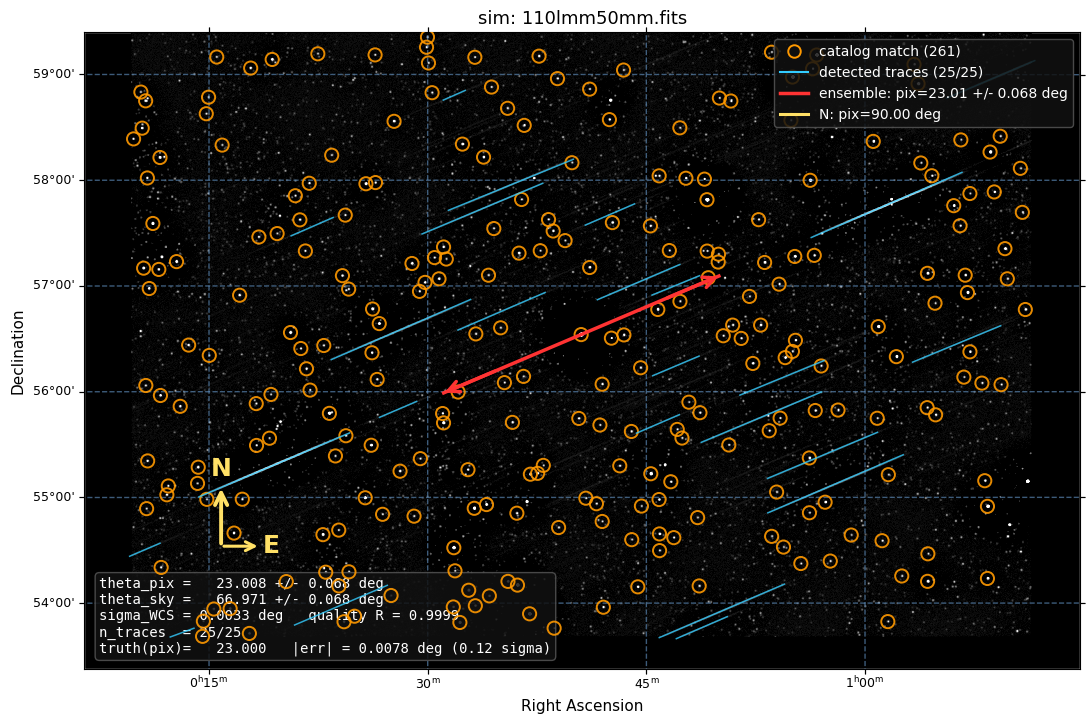

In [7]:
make_main_figure(sim, lo_pct=50.0, hi_pct=99.9, gamma=0.6,
                  compass_xy_frac=(0.10, 0.15), compass_len_frac=0.10,
                  ensemble_xy_frac=(0.5, 0.5), ensemble_len_frac=0.5,
                  truth_pix_deg=SIM_TRUTH_DEG, save_name='sim_main_figure.png')


### Sim: bootstrap distributions

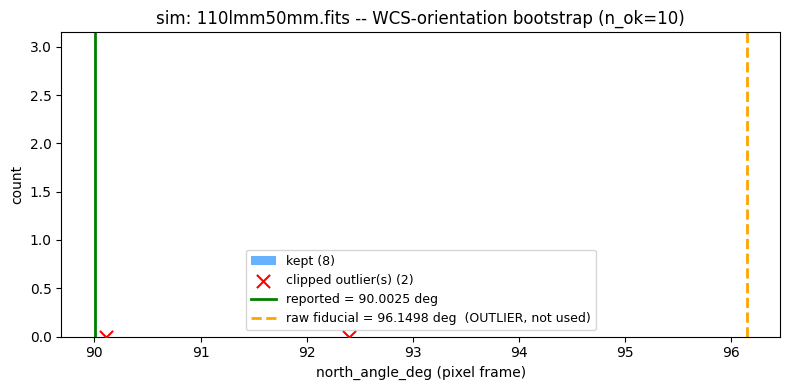

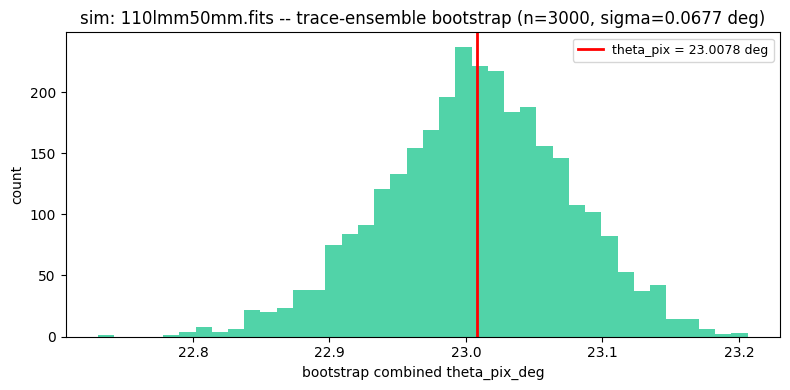

In [8]:
plot_wcs_bootstrap(sim, save_name='sim_wcs_bootstrap.png')
plot_trace_bootstrap(sim, save_name='sim_trace_bootstrap.png')


### Real: main figure

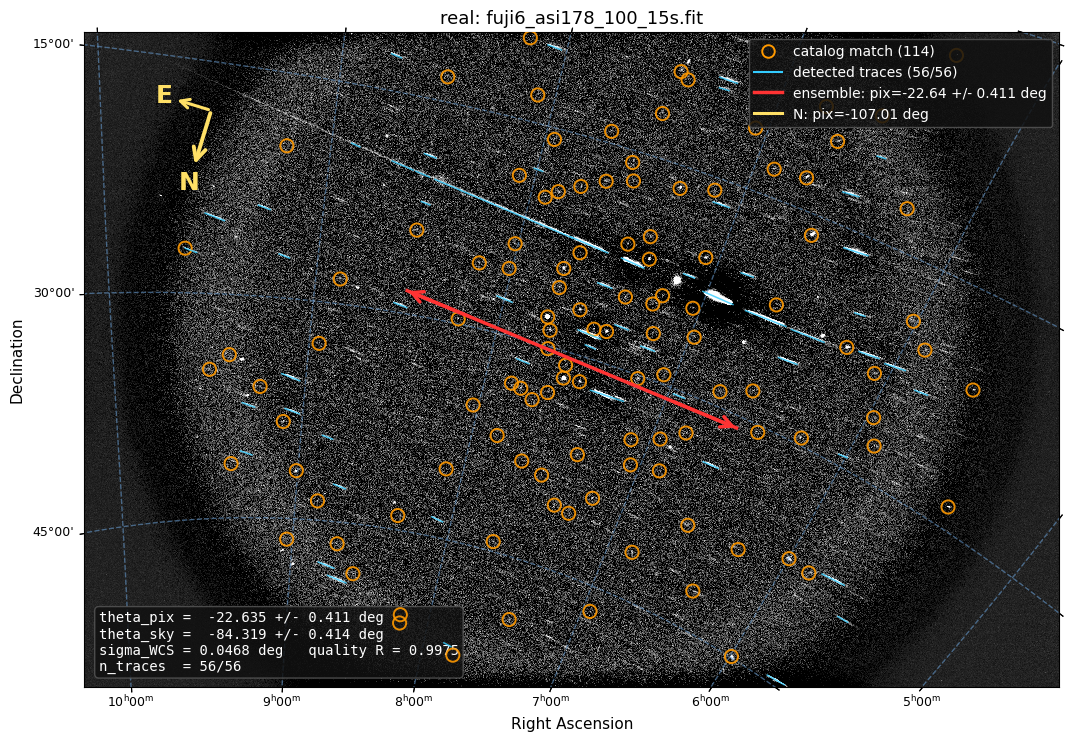

In [9]:
# compass placed top-left (not bottom-left like the sim figure): this
# image's north_angle_deg (~-107 deg) points mostly DOWNWARD in pixel
# space, so a bottom-left compass origin would send the N arrow straight
# into the stats box below it. The compass has to be repositioned per
# image because its arrow directions depend on the actual solved
# orientation, not a fixed layout choice.
make_main_figure(real, lo_pct=30.0, hi_pct=99.8, gamma=0.75,
                  compass_xy_frac=(0.13, 0.88), compass_len_frac=0.09,
                  ensemble_xy_frac=(0.5, 0.5), ensemble_len_frac=0.55,
                  truth_pix_deg=None, save_name='real_main_figure.png')


### Real: bootstrap distributions

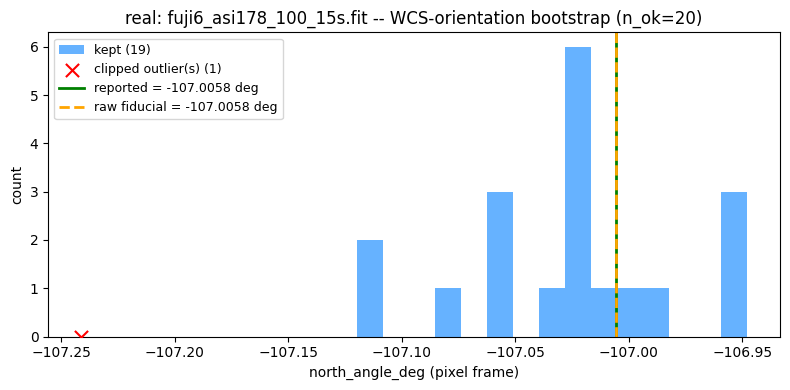

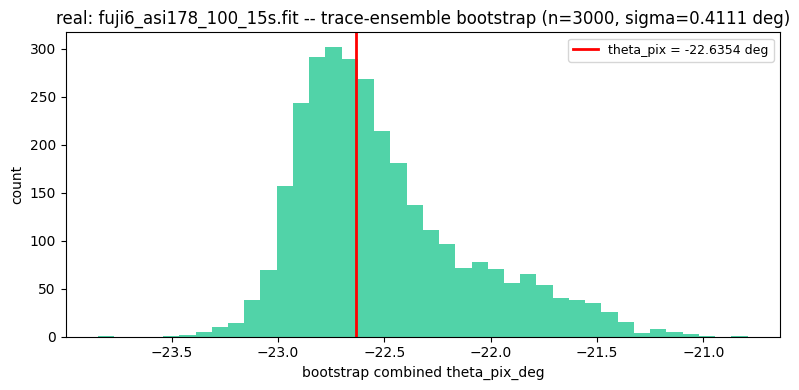

In [10]:
plot_wcs_bootstrap(real, save_name='real_wcs_bootstrap.png')
plot_trace_bootstrap(real, save_name='real_trace_bootstrap.png')


---
## Summary

In [11]:
def summarize(res, truth_pix_deg=None):
    result, boot = res['result'], res['boot']
    print(f"=== {res['label']} ===")
    print(f"  n_traces detected/used : {result.n_traces_detected}/{result.n_traces_used}   quality R = {result.quality:.4f}")
    print(f"  theta_pix               = {result.theta_pix_deg:.4f} +/- {result.theta_pix_uncertainty_deg:.4f} deg  (bootstrap)")
    print(f"    population_scatter    = {result.combined.population_scatter_deg:.4f} deg")
    print(f"    analytical_uncertainty= {result.combined.analytical_uncertainty_deg:.4f} deg")
    print(f"  sigma_WCS                = {boot.sigma_north_deg:.4f} deg  (mad={boot.mad_north_deg:.4f}, "
          f"n_ok={boot.n_boot_ok}/{boot.n_boot_requested}, n_clipped={boot.n_boot_clipped}, "
          f"fiducial_is_outlier={boot.fiducial_is_outlier})")
    print(f"  theta_sky                = {result.theta_sky_deg:.4f} +/- {result.theta_sky_uncertainty_deg:.4f} deg")
    if truth_pix_deg is not None:
        err = abs(((result.theta_pix_deg - truth_pix_deg + 90) % 180) - 90)
        print(f"  ground truth (pix)       = {truth_pix_deg:.4f} deg   |error| = {err:.4f} deg "
              f"({err / result.theta_pix_uncertainty_deg:.2f} sigma from truth)")
    print()


summarize(sim, truth_pix_deg=SIM_TRUTH_DEG)
summarize(real)


=== sim: 110lmm50mm.fits ===
  n_traces detected/used : 25/25   quality R = 0.9999
  theta_pix               = 23.0078 +/- 0.0677 deg  (bootstrap)
    population_scatter    = 0.3640 deg
    analytical_uncertainty= 0.0430 deg
  sigma_WCS                = 0.0033 deg  (mad=0.0028, n_ok=10/10, n_clipped=2, fiducial_is_outlier=True)
  theta_sky                = 66.9707 +/- 0.0678 deg
  ground truth (pix)       = 23.0000 deg   |error| = 0.0078 deg (0.12 sigma from truth)

=== real: fuji6_asi178_100_15s.fit ===
  n_traces detected/used : 56/56   quality R = 0.9975
  theta_pix               = -22.6354 +/- 0.4111 deg  (bootstrap)
    population_scatter    = 2.0306 deg
    analytical_uncertainty= 0.1004 deg
  sigma_WCS                = 0.0468 deg  (mad=0.0267, n_ok=20/20, n_clipped=1, fiducial_is_outlier=False)
  theta_sky                = -84.3188 +/- 0.4137 deg



---
## Note on the sigma_WCS bug found this session

The sim image's `fiducial_is_outlier` flag above should read `True`: the
full-287-source-list plate solve locked onto a confidently-wrong answer
(log-odds 23.3, "84 match, 0 conflict" -- astrometry.net's own confidence
metric gave no warning) 6 deg away from the correct orientation. This was
confirmed against the sim's own ground truth (`ROTDEG=0.0` in the FITS
header, and the pixel-to-sky convention in `tele-img-sim/sim/frame.py`,
which shows north points exactly along +y with no rotation). Most of the
bootstrap's stratified subsets (missing just the handful of sources
responsible for the false match) correctly found the true answer, and
`bootstrap_wcs_orientation` now uses that cross-check to catch and
correct for exactly this failure mode automatically -- see
`extractor/wcs_uncertainty.py`'s module docstring and
`WcsBootstrapResult.fiducial_is_outlier`/`.n_boot_clipped`.

**Takeaway for any future image**: a single high-confidence plate solve
is not automatically trustworthy. Always bootstrap and check
`fiducial_is_outlier` before reporting a WCS orientation.
